#  Locations of drone LiDAR capture


## Import libraries

In [1]:
import os
import numpy as np
import xarray as xr
import geopandas as gpd
import rioxarray as rxr
import contextily as ctx
import matplotlib.pyplot as plt

from odc.geo import BoundingBox
from odc.geo.xr import assign_crs

### Loop through canopy height data and extracting locations

In [2]:
chm_tifs = [i for i in os.listdir('results/chm_tifs') if i.endswith('tif')]

In [3]:
polys = {}
for tif in chm_tifs:
    
    name = tif.split('.')[0]

    # open canopy height data
    chm = rxr.open_rasterio(f'results/chm_tifs/{tif}').squeeze().drop_vars('band')
    poly=chm.odc.geobox.to_crs('EPSG:4326').boundingbox.boundary().convex_hull    
    polys[name] = poly.centroid


In [4]:
gdf = gpd.GeoDataFrame(
    {"plot_id": list(polys.keys())},
    geometry=list(polys.values()),
    crs="EPSG:4326"  # Set CRS if known
)

### Plot

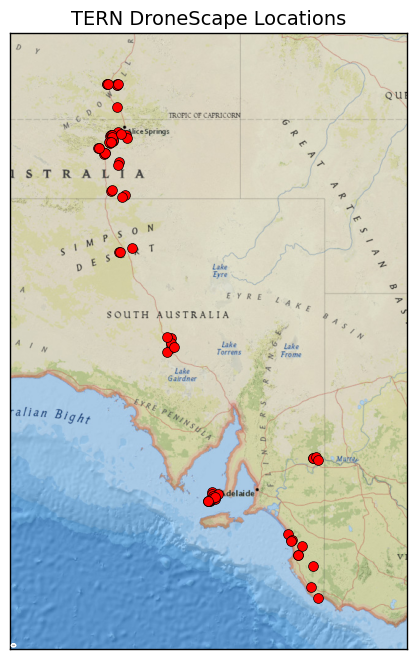

In [5]:
# --- Plotting ---
fig, ax = plt.subplots(figsize=(8, 8))

# Reproject to Web Mercator (required for contextily basemaps)
gdf_webmerc = gdf.to_crs(epsg=3857)

# Calculate bounds and add padding
xmin, ymin, xmax, ymax = gdf_webmerc.total_bounds
xpad = (xmax - xmin) * 0.4  # 30% padding
ypad = (ymax - ymin) * 0.1

# Plot points
gdf_webmerc.plot(
    ax=ax,
    # column='plot_id',
    color="red",
    markersize=50,
    edgecolor="black",
    linewidth=0.5,
    zorder=2,
)

# Set expanded limits before adding basemap
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

# Add basemap
ctx.add_basemap(ax, 
                source=ctx.providers.Esri.NatGeoWorldMap,
                attribution='ESRI',
                attribution_size=1)  # nice terrain map

# Clean up plot
# Add black border around axis
for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1)

# Clean up (but keep spines visible)
ax.set_xticks([])
ax.set_yticks([])
# ax.set_axis_off()
ax.set_title("TERN DroneScape Locations", fontsize=14)
ax.margins(0.1)
plt.savefig(f"results/drone_locations.png", dpi=300, bbox_inches="tight")